### Simulation Investigation into Conditional Trend Filtering and Changepoint Detection on High-Frequency Price Process

Jason Bohne

Jason.bohne@stonybrook.edu

Applied Math and Stats Ph.D. Student 

Under Supervision of Professor Pawel Polak



In [1]:
import sys
import numpy as np
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt


path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')

from kernel_smoother import smooth_series, cv_block_size, mom_kde
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### Prep Data

- First minute seconds of trade data for AAPL after open across availble U.S. equity exchanges
- Benchmark model for seconds however can extend to any time interval
- Group observations by participant side timestamp; averaging price and summing volume
- Results in ~1400 observations
- Preprocessed and cleaned to remove trades executed before open

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0).dropna()
trades=trades[trades.index < "2020-01-02 09:42:00"]
trades=trades[trades.index> "2020-01-02 09:40:00"]
trades.index=pd.to_datetime(trades.index)
trades['Index']=trades.index
trades=trades.groupby('Index').agg({'Trade_Price':np.mean, 'Trade_Volume':np.sum})


trades['Trade_Price']=np.log(trades['Trade_Price'])
trades=trades[trades['Trade_Volume']<1000]




### Hyperparameters
- Prior Series $X_T$
- Number of Local Max; N
- Stationary Variance $\sigma^2$

In [3]:
N=10
variance=0.25
sample_variance=0.25

### Step 1; Generate Prior

- In our analysis trade volume will be used as a prior for changes in underlying price trend however any discrete series can be utilized (realized volatility)
- Normalize time of prior to be incremented in total seconds

In [4]:
original_index=trades['Trade_Volume'].index
volume_index=[(i -original_index[0]).total_seconds() for i in original_index]
volume_prior=trades['Trade_Volume'].values

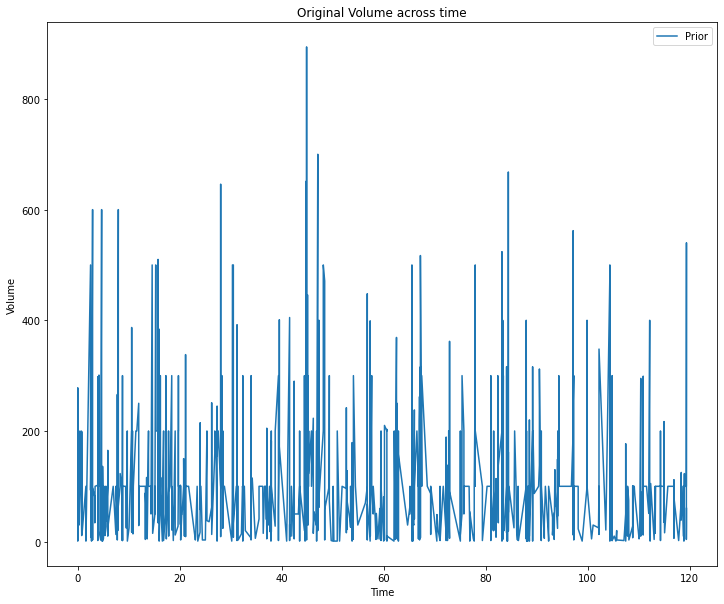

In [5]:
fig,ax=plt.subplots(figsize=(12,10))
plt.title("Original Volume across time")
plt.ylabel("Volume")
plt.xlabel("Time")
plt.plot(volume_index,volume_prior,label="Prior")
plt.legend()

### Step 2; Identify spikes in volume 
- Assumes changes in underlying trend occur within some d- neighborhood here
- Such that d is a hyperparameter prespecified

In [60]:
def remove_consecutive_max(indices,values,d):
 
    tuples=[(i,i+1) for i in range(0,len(indices))]

    diff_dict=dict(zip(tuples,np.diff(indices)))
    diff_list=sorted(diff_dict.items(),key=lambda x:x[1])
    list_indices=[i[0] for i in diff_list if i[1]<d]
    remove_indices=[i[np.argmin(np.array([values[i[0]-1],values[i[1]-1]]))] for i in list_indices]
    
    indices_to_keep=np.setdiff1d(np.arange(0,len(indices),1),remove_indices)
    
    return indices_to_keep


def find_max(prior,count,d=None):
    """ Find max n values of a series constrained to have certain distance d
    """
    
    if d is None:
        d=len(prior)/10
        
    series=dict(zip(np.arange(0,len(prior)),prior))
    sorted_series=sorted( series.items(), key=lambda x:x[1],reverse=True)[:count]
    sorted_series=sorted(sorted_series, key=lambda x:x[0])
    
    indices=np.array([i[0] for i in sorted_series])
    values=np.array([i[1] for i in sorted_series])
    
    
    indices_to_keep=remove_consecutive_max(indices,values,d)
    
    new_indices=indices[indices_to_keep]
    new_values=values[indices_to_keep]
    
    return new_indices,new_values
    
indices,values=find_max(volume_prior,N)
indices

array([ 147,  393,  707, 1113, 1227])

### Step 3 ; Generate True Underlying Trend

- Given identified max values iterate forward at some linear rate
- Each change in underlying series is sampled from a normal distribution of variance prespecified 
- Interpretation is that most consecutive values will be piecewise linear with small noise; with sparse jumps arising from larger variance 


In [150]:
def generate_true_underlying(changepoints,variance,prior,prior_index=None,init=0,init_step=0.001,threshold=1,seed=12456):
    """ Simulate price process as piecewise linear between selected changepoints; scaling distance btwn consecutive cp
    """
    np.random.seed(seed)
    if prior_index is None:
        prior_index=np.ones(len(prior))
    
    # thresholding unit time 
    prior_index=np.fmax(prior_index,1)
    
    def compute_init_step(x0):
        """ Compute initial step to determine slope
        """
        stand_norm=np.random.normal(size=1)[0] # equal prob up or down
        x1=x0+(np.sign(stand_norm)*init_step)
        return x1
        
    increment,counter=0,0
    skip_step=False
    x0=0
    x1=compute_init_step(x0)
    
    N=len(prior)
    samples=[]
    samples.append(x0)
    samples.append(x1)

    
    for point in range(0,N):
        time_step=prior_index[point]
        if skip_step:
            skip_step=False
            continue
        
        if  increment<len(changepoints):
            if  point==changepoints[increment] :
                next_time_step=prior_index[point+1]
                
                increment+=1
                mu=samples[point-1]+time_step*(samples[point-1]-samples[point-2]) # location
                
                scale=variance

                sample=np.random.normal(loc=mu,scale=scale,size=1)[0]
                samples.append(sample)
                
                new_step=compute_init_step(sample)
                samples.append(new_step)
              
                skip_step=True
                
            else:
                s_i=samples[-1]+time_step*(samples[-1]-samples[-2])
                
                samples.append(s_i)
                
            
        else:
        
            s_i=samples[-1]+time_step*(samples[-1]-samples[-2])
           
     
            samples.append(s_i)
            
   
    samples.pop(0)
    samples.pop(0)
    return np.array(samples)+init

In [151]:
true_series=generate_true_underlying(indices,variance,volume_prior,init=50)

Text(0.5, 1.0, 'Simulated Path Equal Time')

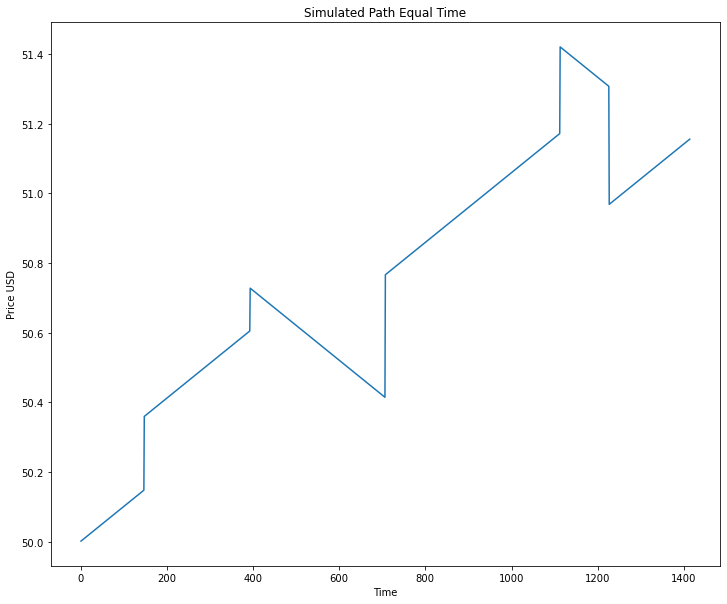

In [152]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path Equal Time")

### Step 4;  Generate normal sample of discrete process with centered locaiton parameters and prespecified variance parameter

In [153]:
def sample_discrete_process(true_series,sample_variance,seed=12456):
    np.random.seed(seed)
    def generate_normal(mu,variance):
        return np.random.normal (loc=mu,scale=sample_variance,size=1)[0]
    
    samples=[generate_normal(mu,sample_variance) for mu in true_series]
    
    return np.array(samples)

x_i=sample_discrete_process(true_series,sample_variance)

Text(0.5, 1.0, 'Simulated Path')

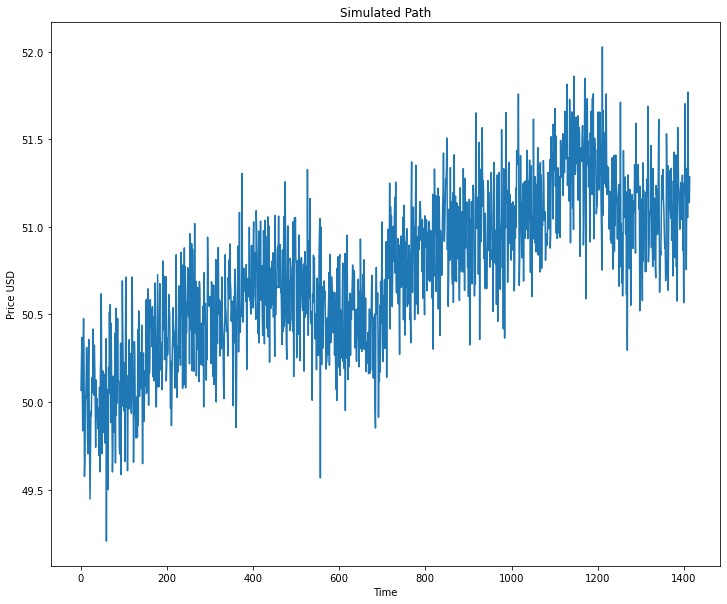

In [154]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

### Numerical Results 1; L1 trend filtering 

- Given the simulated path from step 5; we wish to apply L1 trend filtering to the problem
- Incorporates irregular spacing between observations
- Constrains our estimator to be piecewise linear 
- Here the penalty is set to a constant; dictated by our sensitivity to number of changepoints
    - Hyperparameter can be cross validated

In [155]:
trend_filter_series,status,D=l1tf_adaptive_ir(x_i.reshape(-1,1),t=volume_index,lambda_p=50)

pobj1: [[2.46912031e+10]], pobj2: [[3.4738968e+09]], dobj: [[0.]], gap: [[3.4738968e+09]]
pobj1: [[7.98471672e+16]], pobj2: [[94.80863904]], dobj: [[43.54517857]], gap: [[51.26346047]]
pobj1: [[3.98888077e+16]], pobj2: [[56.44620881]], dobj: [[46.62674133]], gap: [[9.81946748]]
pobj1: [[9.12106152e+17]], pobj2: [[54.73510598]], dobj: [[46.77415215]], gap: [[7.96095383]]
pobj1: [[4.79357701e+16]], pobj2: [[53.34784492]], dobj: [[47.15899118]], gap: [[6.18885374]]
pobj1: [[1.4285194e+16]], pobj2: [[51.87818037]], dobj: [[47.43552492]], gap: [[4.44265545]]
pobj1: [[6.2257729e+16]], pobj2: [[51.09796085]], dobj: [[47.7303296]], gap: [[3.36763125]]
pobj1: [[2.10971902e+18]], pobj2: [[50.73012156]], dobj: [[47.75999742]], gap: [[2.97012414]]
pobj1: [[1.57863645e+15]], pobj2: [[50.3857547]], dobj: [[47.76974381]], gap: [[2.61601089]]
pobj1: [[6.75558961e+15]], pobj2: [[49.81466927]], dobj: [[48.00349898]], gap: [[1.81117029]]
pobj1: [[2.62232358e+17]], pobj2: [[49.69810309]], dobj: [[48.01706

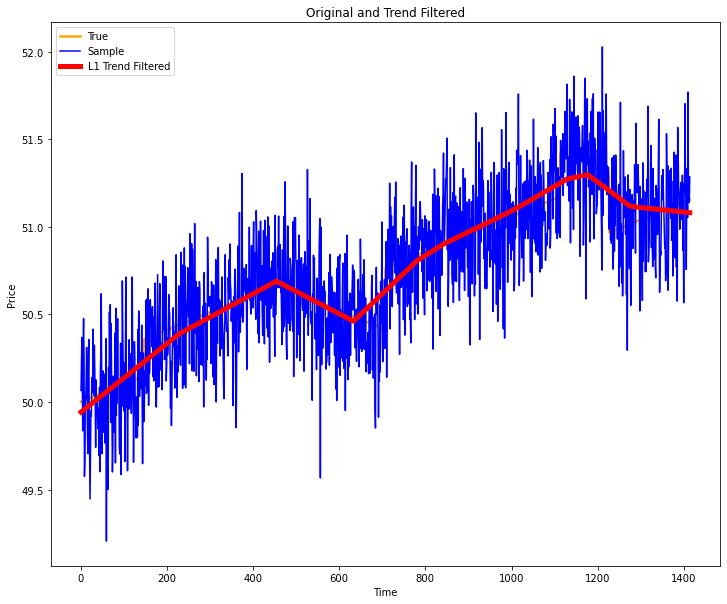

In [156]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=2.5,color='orange')
plt.plot(x_i,label='Sample',color='blue')
plt.plot(trend_filter_series,label='L1 Trend Filtered',lw=5,color='red')
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Numerical Result 1; Conditional Adaptive L1 trend filtering  
- Estimator is piecewise linear accounting for irregular observations
- Sensitivity of estimator to changes in underlying trend is conditional on inverse of prior 
- Included explicitly as adaptive penalty (scaled by scale_factor)

In [157]:
scale_factor=100

adaptive_trend_filter_series,status,D=l1tf_adaptive_ir(x_i.reshape(-1,1),t=volume_index,lambda_p=scale_factor*1/volume_prior[1:-1])
adaptive_trend_filter_series=adaptive_trend_filter_series.reshape(1,-1)[0][1:-1]

pobj1: [[1.4459611e+10]], pobj2: [[7.93783794e+08]], dobj: [[0.]], gap: [[7.93783794e+08]]
pobj1: [[1.33781848e+19]], pobj2: [[72.0290535]], dobj: [[41.38155044]], gap: [[30.64750307]]
pobj1: [[9.7365916e+17]], pobj2: [[45.01057944]], dobj: [[42.61852372]], gap: [[2.39205572]]
pobj1: [[1.92340943e+19]], pobj2: [[44.47229051]], dobj: [[42.74050669]], gap: [[1.73178382]]
pobj1: [[7.51049366e+18]], pobj2: [[44.25437928]], dobj: [[42.78370369]], gap: [[1.47067559]]
pobj1: [[5.50302206e+18]], pobj2: [[43.99029231]], dobj: [[42.88313809]], gap: [[1.10715422]]
pobj1: [[2.53012593e+19]], pobj2: [[43.84259215]], dobj: [[42.89762902]], gap: [[0.94496313]]
pobj1: [[4.22848056e+18]], pobj2: [[43.74357146]], dobj: [[42.92592839]], gap: [[0.81764307]]
pobj1: [[2.14651836e+18]], pobj2: [[43.65102699]], dobj: [[42.95149922]], gap: [[0.69952777]]
pobj1: [[5.32032081e+17]], pobj2: [[43.61344546]], dobj: [[42.96164038]], gap: [[0.65180508]]
pobj1: [[1.85077287e+18]], pobj2: [[43.55350474]], dobj: [[42.99

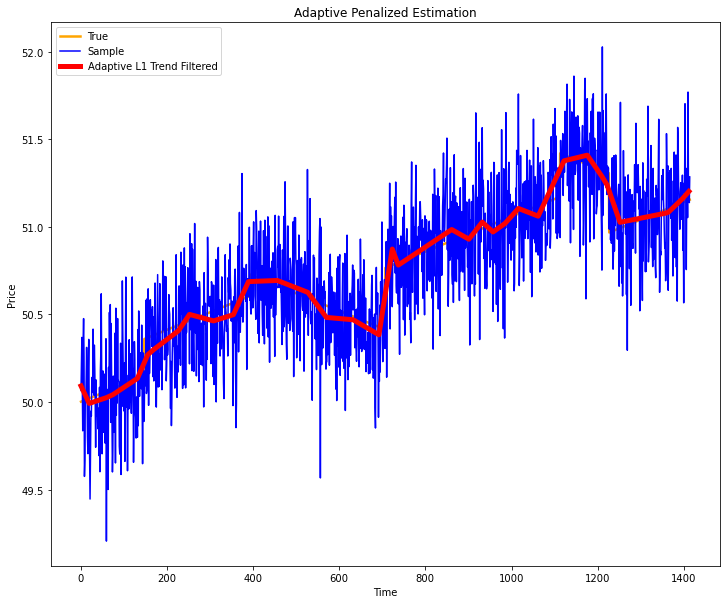

In [158]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=2.5,color='orange')
plt.plot(x_i,label='Sample',color='blue')
plt.plot(adaptive_trend_filter_series,label='Adaptive L1 Trend Filtered',lw=5,color='red')
plt.title("Adaptive Penalized Estimation")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Step 7; Changepoint Extraction

- As estimator is piecweise linear; changepoints can be recovered in both simulations with second order difference operator
- Recovered changepoints plotted below; marked in black
- Threshold for occurrence of changepoint is another hyperparameter to be tuned

In [159]:
def extract_cp(smooth,difference_order=2,threshold=1e-6):
    """ Extract changepoints via difference operator 
    """
    diff_mat=Dmat(len(smooth),2).todense()
    diff=np.dot(diff_mat,smooth).reshape(1,-1)[0]
    
    x,y,index=np.where([abs(diff)>threshold])
    return index

In [160]:
changepoints=extract_cp(trend_filter_series)
adaptive_changepoints=extract_cp(adaptive_trend_filter_series,threshold=1e-4)

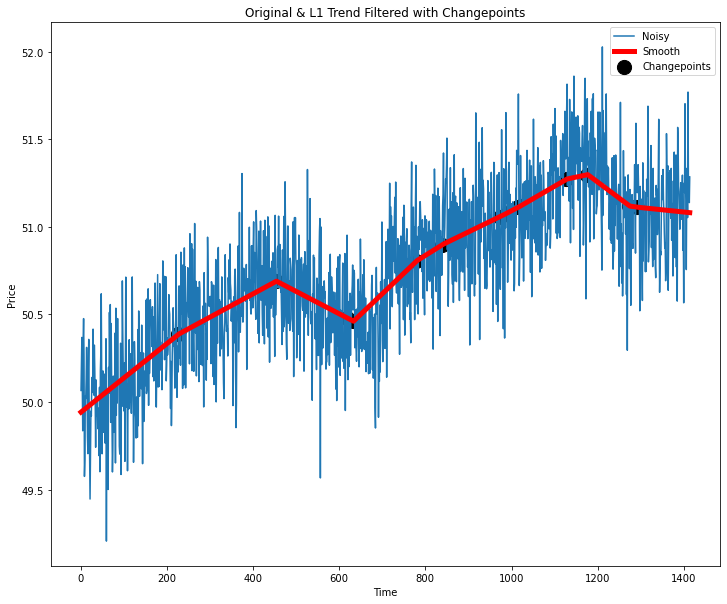

In [161]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i,label='Noisy')
plt.plot(trend_filter_series,label='Smooth',lw=5,color='red')
plt.scatter(np.arange(0,len(x_i),1)[changepoints],trend_filter_series[changepoints],color='black',s=200,label='Changepoints')
plt.title("Original & L1 Trend Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

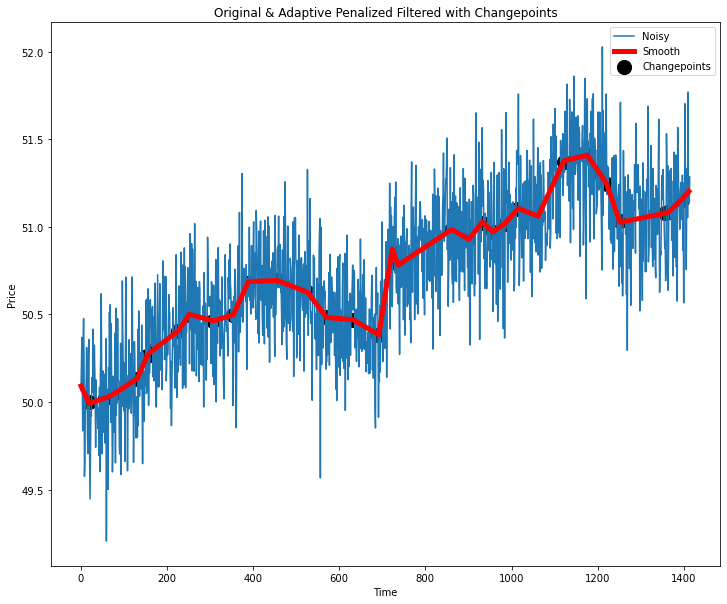

In [162]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(x_i,label='Noisy')
plt.plot(adaptive_trend_filter_series,label='Smooth',lw=5,color='red')
plt.scatter(np.arange(0,len(x_i),1)[adaptive_changepoints],adaptive_trend_filter_series[adaptive_changepoints],color='black',s=200,label='Changepoints')
plt.title("Original & Adaptive Penalized Filtered with Changepoints")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Instability in Time

Visualizing against true time increments

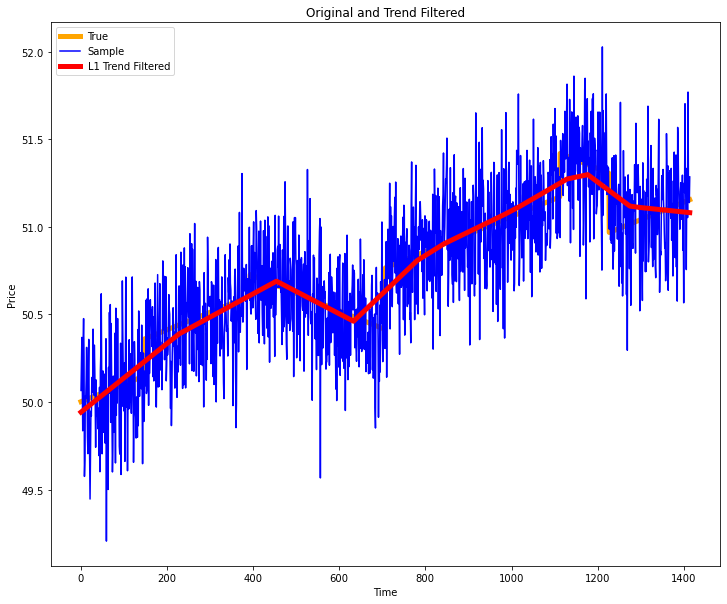

In [163]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(true_series,label='True', lw=5,color='orange')
plt.plot(x_i,label='Sample',color='blue')
plt.plot(trend_filter_series,label='L1 Trend Filtered',lw=5,color='red')
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()

### Passing in original time increments

Generate true signal assuming time increments; thresholding internally for numerical stability

In [164]:
diff_index=np.diff(volume_index)
concat_index=np.append(diff_index,np.mean(diff_index))

time_spaced_series=generate_true_underlying(indices,variance,volume_prior,concat_index,init=50)


Text(0.5, 1.0, 'Simulated Path off True Time Steps')

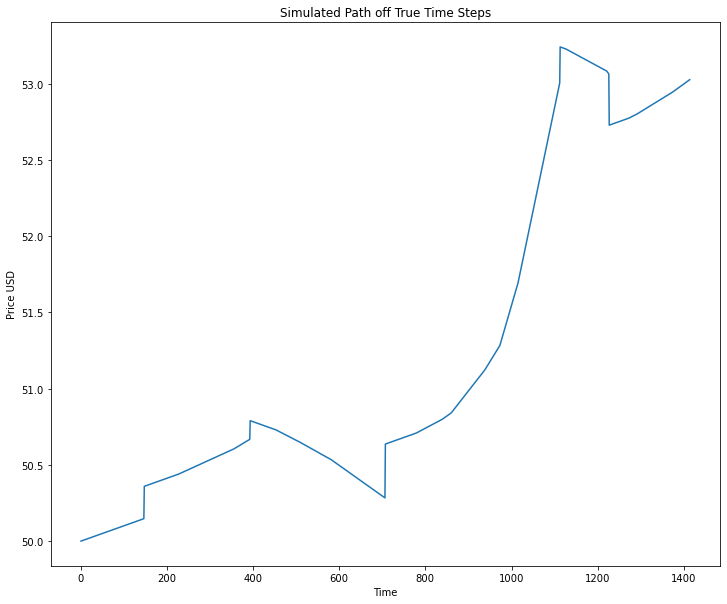

In [165]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(time_spaced_series)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path off True Time Steps")

In [166]:
x_i_time=sample_discrete_process(time_spaced_series,sample_variance)

Text(0.5, 1.0, 'Simulated Path')

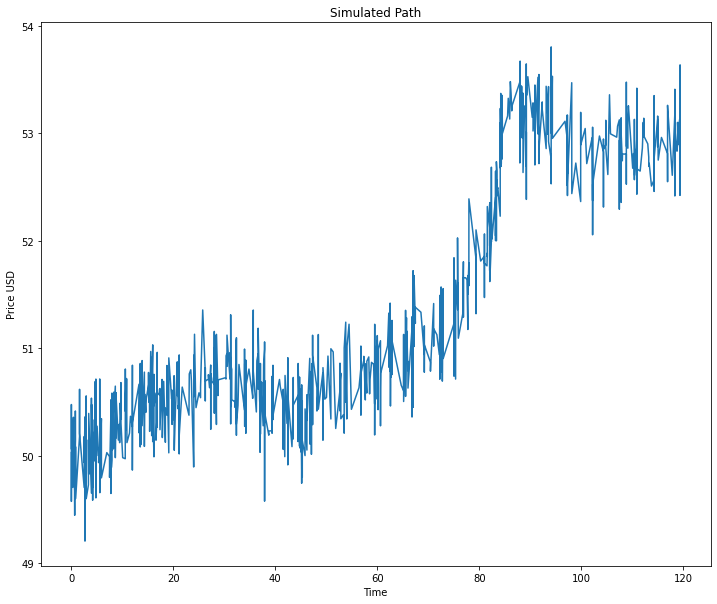

In [167]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(volume_index,x_i_time)
plt.xlabel("Time")
plt.ylabel("Price USD")
plt.title("Simulated Path")

In [168]:
trend_filter_series_time,status,D=l1tf_adaptive_ir(x_i_time.reshape(-1,1),t=volume_index,lambda_p=50)

pobj1: [[7.13796162e+11]], pobj2: [[3.47155733e+09]], dobj: [[0.]], gap: [[3.47155733e+09]]
pobj1: [[8.1994223e+16]], pobj2: [[99.29866406]], dobj: [[43.73811874]], gap: [[55.56054531]]
pobj1: [[3.24209096e+18]], pobj2: [[73.45499943]], dobj: [[47.28763823]], gap: [[26.1673612]]
pobj1: [[4.003046e+17]], pobj2: [[64.14045472]], dobj: [[47.94841465]], gap: [[16.19204007]]
pobj1: [[5.81478087e+16]], pobj2: [[59.19629741]], dobj: [[49.62443794]], gap: [[9.57185947]]
pobj1: [[1.52460382e+16]], pobj2: [[56.0897991]], dobj: [[50.1955282]], gap: [[5.8942709]]
pobj1: [[2.59559607e+14]], pobj2: [[53.72801722]], dobj: [[51.3111135]], gap: [[2.41690372]]
pobj1: [[2.688719e+14]], pobj2: [[53.23134783]], dobj: [[51.63640356]], gap: [[1.59494427]]
pobj1: [[5.21458275e+13]], pobj2: [[52.68816986]], dobj: [[52.54388471]], gap: [[0.14428515]]
pobj1: [[1.59151476e+13]], pobj2: [[52.64210536]], dobj: [[52.63399977]], gap: [[0.00810559]]
solved
pobj1: [[1.59151476e+13]], pobj2: [[52.64210536]], dobj: [[52.

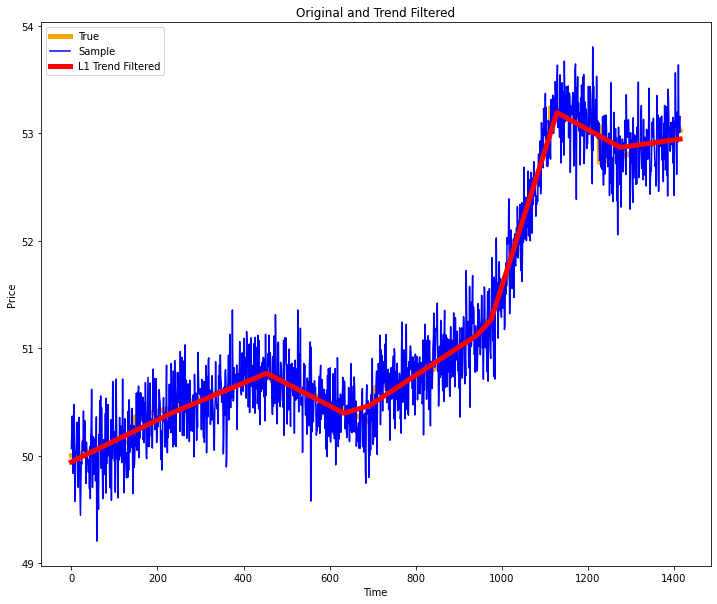

In [169]:
fig,ax=plt.subplots(figsize=(12,10))
plt.plot(time_spaced_series,label='True', lw=5,color='orange')
plt.plot(x_i_time,label='Sample',color='blue')
plt.plot(trend_filter_series_time,label='L1 Trend Filtered',lw=5,color='red')
plt.title("Original and Trend Filtered")
plt.xlabel("Time")
plt.ylabel('Price')
plt.legend()